**Project UAS Pembelajaran Mesin Dasar 2024 A**

Dosen pengampu: Dr. Heri Purnawan, S.Si., M.Si.

Kelompok 9:

1. Nor Hofifah (24031554009)

2. Zahra Brillianty Putri (24031554014)

3. Khofifah Dwi Sanni El Randi (24031554156)

Dataset:

https://www.kaggle.com/datasets/rxnach/student-stress-factors-a-comprehensive-analysis

Referensi:
https://www.researchgate.net/publication/396771472_Classification_of_Student_Stress_Levels_Using_Machine_Learning_Methods


### **Import Library**

In [2]:
pip install xgboost

     ------------------------------------ 101.7/101.7 MB 971.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.metrics import confusion_matrix

### **Load Dataset**

In [4]:
df = pd.read_csv('StressLevelDataset.csv')

In [5]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2


### **Eksplorasi Dataset**

In [6]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [7]:
df.shape

(1100, 21)

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    1100 non-null 

In [9]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


### **Visualisasi EDA**

Distribusi tingkat stres

In [10]:
stress_count = df['stress_level'].value_counts()

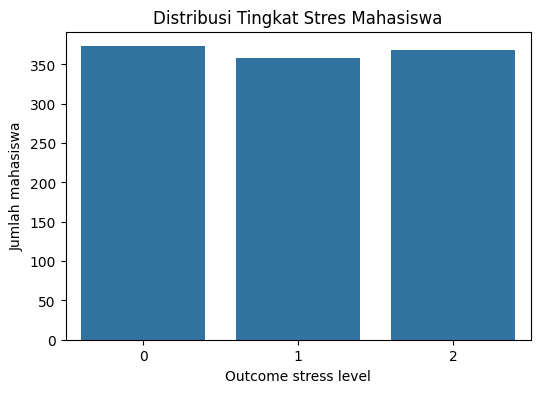

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='stress_level',
    data=df
)

plt.title('Distribusi Tingkat Stres Mahasiswa')
plt.xlabel('Outcome stress level')
plt.ylabel('Jumlah mahasiswa')

plt.show()

In [12]:
#fitur faktor yang memengaruhi tingkat stres
fitur_stres = [
    'academic_performance',
    'sleep_quality',
    'anxiety_level',
    'peer_pressure',
    'living_conditions',
    'mental_health_history'
]

Distribusi faktor yang memengaruhi tingkat stres

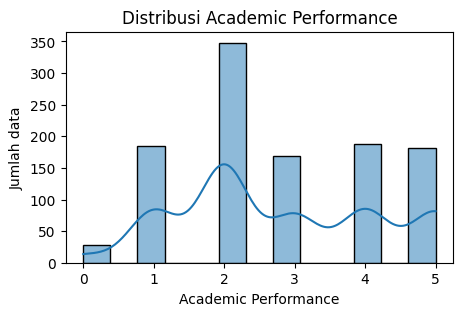

In [13]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='academic_performance',
    kde=True
)

plt.title('Distribusi Academic Performance')
plt.xlabel('Academic Performance')
plt.ylabel('Jumlah data')

plt.show()

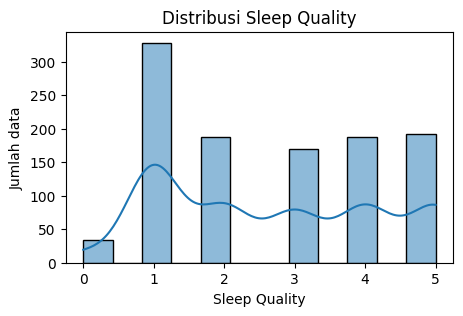

In [14]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='sleep_quality',
    kde=True
)

plt.title('Distribusi Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Jumlah data')

plt.show()

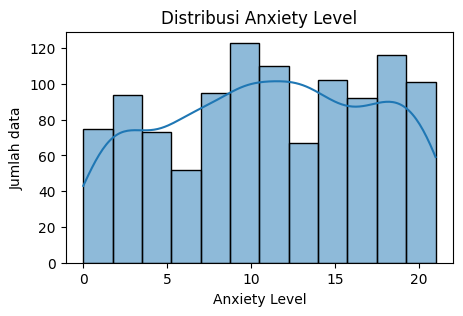

In [15]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='anxiety_level',
    kde=True
)

plt.title('Distribusi Anxiety Level')
plt.xlabel('Anxiety Level')
plt.ylabel('Jumlah data')

plt.show()

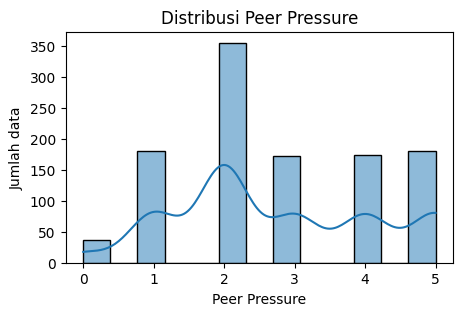

In [16]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='peer_pressure',
    kde=True
)

plt.title('Distribusi Peer Pressure')
plt.xlabel('Peer Pressure')
plt.ylabel('Jumlah data')

plt.show()

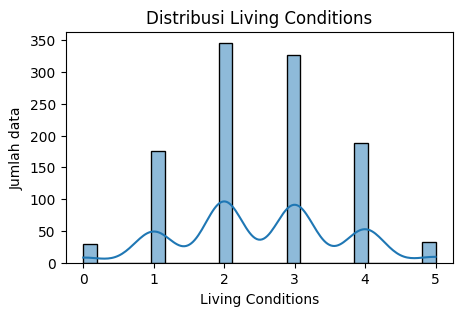

In [17]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='living_conditions',
    kde=True
)

plt.title('Distribusi Living Conditions')
plt.xlabel('Living Conditions')
plt.ylabel('Jumlah data')

plt.show()

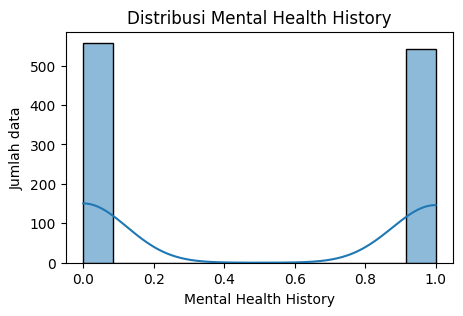

In [18]:
plt.figure(figsize=(5,3))

sns.histplot(
    data=df,
    x='mental_health_history',
    kde=True
)

plt.title('Distribusi Mental Health History')
plt.xlabel('Mental Health History')
plt.ylabel('Jumlah data')

plt.show()

Matriks korelasi

In [19]:
#membuat matriks korelasi
correlation_matrix = df.corr(numeric_only=True)

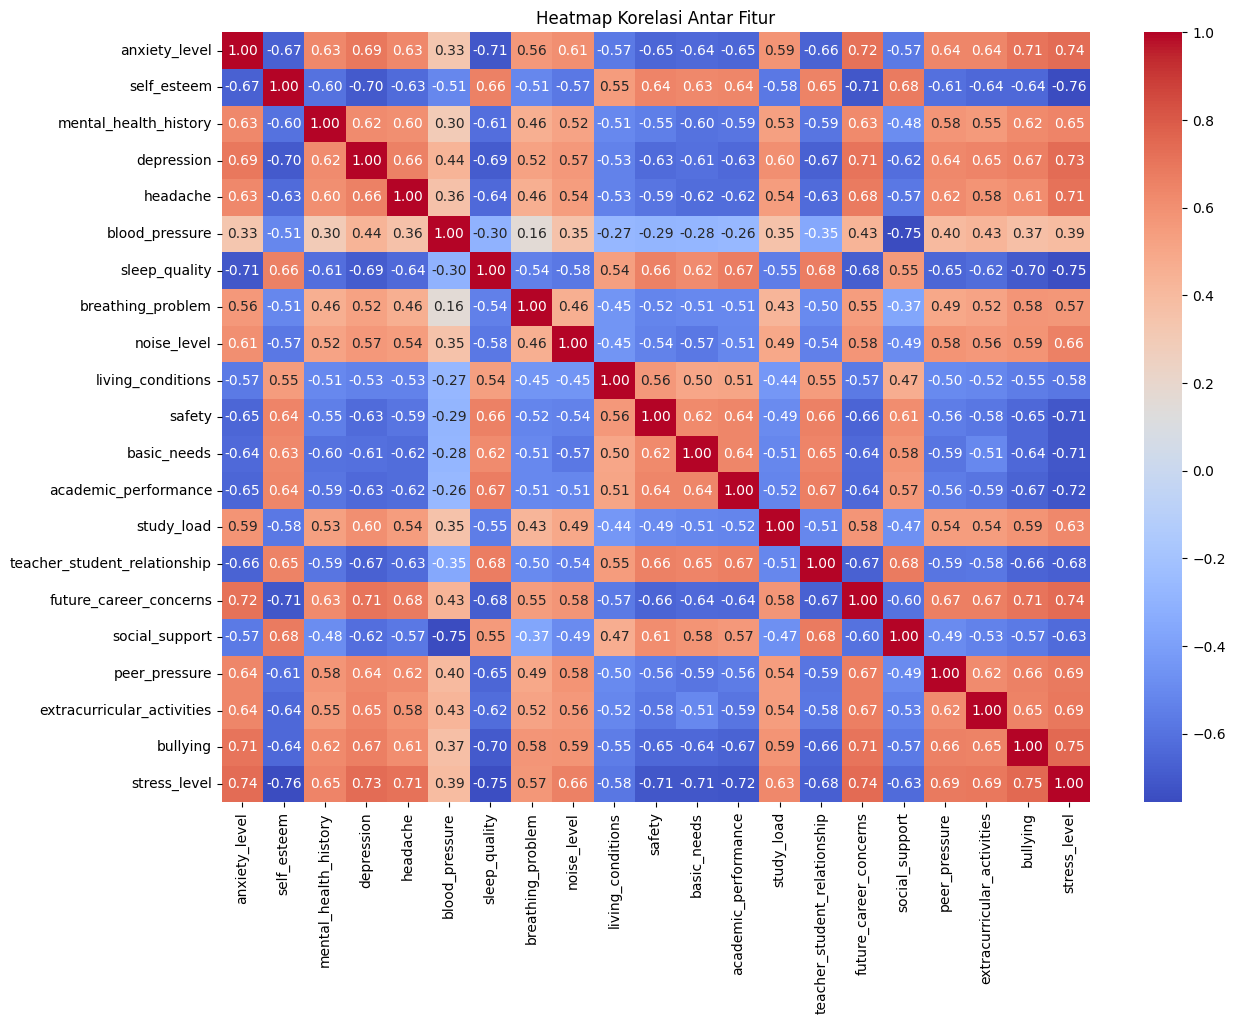

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# **CASE 1 - DATA ASLI**

### **Preprocessing**

Cek missing value

In [21]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Cek data duplikat

In [22]:
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 0


Memisahkan data input dan output

In [23]:
X = df.drop('stress_level', axis=1)
print('Jumlah fitur:', X.shape)

Jumlah fitur: (1100, 20)


In [24]:
y = df['stress_level']
print('Jumlah target:', y.shape)

Jumlah target: (1100,)


### **Split Data**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print('Jumlah data training:', X_train.shape)
print('Jumlah data testing:', X_test.shape)

Jumlah data training: (880, 20)
Jumlah data testing: (220, 20)


### **Imputasi**

In [27]:
imputer = SimpleImputer(
    strategy='mean'
)

# Melakukan imputasi pada data training
X_train = imputer.fit_transform(
    X_train
)

# Melakukan imputasi pada data testing
X_test = imputer.transform(
    X_test
)

X_train = pd.DataFrame(
    X_train,
    columns=X.columns
)

X_test = pd.DataFrame(
    X_test,
    columns=X.columns
)

print("DATA TRAINING SETELAH IMPUTASI")
display(X_train.head())

print("DATA TESTING SETELAH IMPUTASI")
display(X_test.head())

DATA TRAINING SETELAH IMPUTASI


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
0,13.0,25.0,1.0,10.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0
1,19.0,11.0,1.0,25.0,4.0,3.0,1.0,5.0,5.0,1.0,1.0,2.0,1.0,4.0,2.0,4.0,1.0,5.0,5.0,5.0
2,1.0,25.0,0.0,3.0,1.0,2.0,5.0,1.0,1.0,4.0,5.0,4.0,4.0,1.0,4.0,1.0,3.0,1.0,2.0,1.0
3,15.0,10.0,1.0,17.0,4.0,3.0,1.0,5.0,5.0,1.0,1.0,2.0,1.0,5.0,1.0,4.0,1.0,5.0,4.0,5.0
4,7.0,27.0,0.0,0.0,1.0,2.0,4.0,2.0,2.0,3.0,5.0,4.0,4.0,1.0,4.0,1.0,3.0,2.0,1.0,1.0


DATA TESTING SETELAH IMPUTASI


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
0,8.0,29.0,0.0,1.0,1.0,2.0,5.0,2.0,1.0,3.0,5.0,4.0,5.0,2.0,5.0,1.0,3.0,2.0,2.0,1.0
1,7.0,25.0,0.0,4.0,1.0,2.0,5.0,1.0,2.0,3.0,5.0,5.0,5.0,1.0,4.0,1.0,3.0,1.0,1.0,1.0
2,15.0,14.0,1.0,19.0,5.0,3.0,1.0,5.0,3.0,2.0,1.0,2.0,2.0,5.0,2.0,5.0,1.0,5.0,5.0,5.0
3,20.0,15.0,1.0,26.0,4.0,3.0,1.0,4.0,4.0,2.0,2.0,2.0,1.0,5.0,1.0,4.0,1.0,5.0,5.0,4.0
4,6.0,11.0,0.0,24.0,4.0,3.0,1.0,1.0,0.0,3.0,4.0,2.0,0.0,3.0,2.0,1.0,1.0,2.0,0.0,1.0


### **Feature Scaling**

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###**Pembangunan & Training Model**

SVM

In [29]:
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

XGBoost

In [31]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

###**Prediksi Model**

In [32]:
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

###**Evaluasi Model**

In [33]:
def evaluasi_model(nama_model, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f'{nama_model}')
    print('Accuracy:', round(accuracy, 4))
    print('Precision:', round(precision, 4))
    print('Recall:', round(recall, 4))
    print('F1-Score:', round(f1, 4))

    print()
    print(classification_report(y_test, y_pred))

SVM

In [34]:
evaluasi_model('SVM', y_test, y_pred_svm)

SVM
Accuracy: 0.8773
Precision: 0.8773
Recall: 0.8773
F1-Score: 0.8771

              precision    recall  f1-score   support

           0       0.87      0.84      0.86        74
           1       0.90      0.92      0.91        72
           2       0.86      0.88      0.87        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



Random Forest

In [35]:
evaluasi_model('Random Forest', y_test, y_pred_rf)

Random Forest
Accuracy: 0.8773
Precision: 0.8782
Recall: 0.8773
F1-Score: 0.8767

              precision    recall  f1-score   support

           0       0.90      0.81      0.85        74
           1       0.88      0.90      0.89        72
           2       0.86      0.92      0.89        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



XGBoost

In [36]:
evaluasi_model('XGBoost', y_test, y_pred_xgb)

XGBoost
Accuracy: 0.8864
Precision: 0.887
Recall: 0.8864
F1-Score: 0.8864

              precision    recall  f1-score   support

           0       0.90      0.86      0.88        74
           1       0.90      0.90      0.90        72
           2       0.86      0.89      0.87        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



### **Hyperparameter Tuning**

Random Forest

In [37]:
from sklearn.model_selection import GridSearchCV

# parameter yang akan diuji
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

# Model Random Forest
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Grid Search CV
grid_rf = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_rf,
    cv=5,
    scoring='accuracy'
)

# training tuning
grid_rf.fit(
    X_train,
    y_train
)

print("PARAMETER TERBAIK:")
print(grid_rf.best_params_)

print("ACCURACY TERBAIK:")
print(round(grid_rf.best_score_, 4))

PARAMETER TERBAIK:
{'max_depth': 3, 'n_estimators': 50}
ACCURACY TERBAIK:
0.8761


In [38]:
best_rf = grid_rf.best_estimator_

# Prediksi data testing
y_pred_best_rf = best_rf.predict(
    X_test
)

best_rf_acc = accuracy_score(
    y_test,
    y_pred_best_rf
)

print("ACCURACY RANDOM FOREST SETELAH TUNING")
print(round(best_rf_acc, 4))

ACCURACY RANDOM FOREST SETELAH TUNING
0.8864


XGBoost

In [39]:
param_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

# Model XGBoost
xgb_tuning = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

# Grid Search
grid_xgb = GridSearchCV(
    estimator=xgb_tuning,
    param_grid=param_xgb,
    cv=5,
    scoring='accuracy'
)

# Training tuning
grid_xgb.fit(
    X_train,
    y_train
)

print("PARAMETER TERBAIK:")
print(grid_xgb.best_params_)

print("ACCURACY TERBAIK:")
print(round(grid_xgb.best_score_, 4))

PARAMETER TERBAIK:
{'max_depth': 7, 'n_estimators': 100}
ACCURACY TERBAIK:
0.8875


In [40]:
best_xgb = grid_xgb.best_estimator_

# Prediksi data testing
y_pred_best_xgb = best_xgb.predict(
    X_test
)

best_xgb_acc = accuracy_score(
    y_test,
    y_pred_best_xgb
)

print("ACCURACY XGBOOST SETELAH TUNING")
print(round(best_xgb_acc, 4))

ACCURACY XGBOOST SETELAH TUNING
0.8682


Tabel Perbandingan Hyperparameter Tuning

In [41]:
rf_acc = accuracy_score(y_test, y_pred_rf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

tuning_df = pd.DataFrame({

    'Model': [
        'Random Forest',
        'XGBoost'
    ],

    'Sebelum Tuning': [
        rf_acc,
        xgb_acc
    ],

    'Sesudah Tuning': [
        best_rf_acc,
        best_xgb_acc
    ]
})

display(tuning_df)

,Model,Sebelum Tuning,Sesudah Tuning
0,Random Forest,0.877273,0.886364
1,XGBoost,0.886364,0.868182


###**Confusion Matrix**

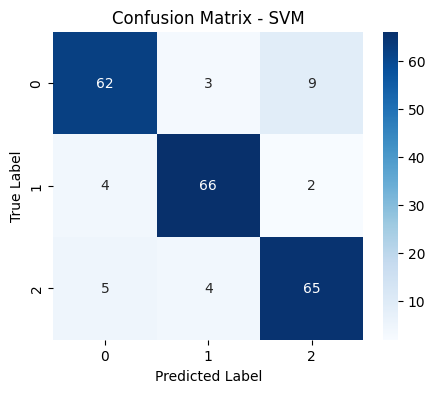

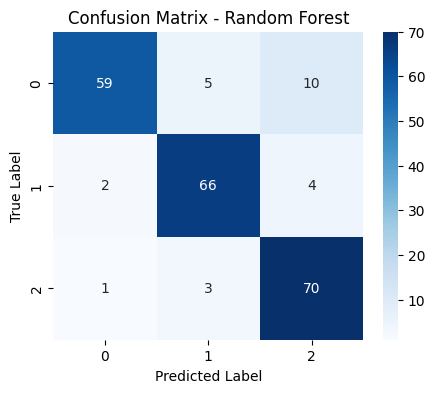

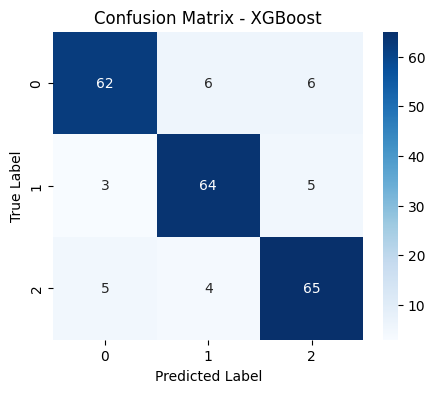

In [42]:
model_prediksi = {

    'SVM': y_pred_svm,
    # Random Forest setelah tuning
    'Random Forest': y_pred_best_rf,
    'XGBoost': y_pred_best_xgb
}


for nama_model, y_pred in model_prediksi.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {nama_model}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.show()

###**Hasil Evaluasi Model**

In [43]:
acc_svm = accuracy_score(
    y_test,
    y_pred_svm
)

prec_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

rec_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

acc_rf = accuracy_score(
    y_test,
    y_pred_best_rf
)

prec_rf = precision_score(
    y_test,
    y_pred_best_rf,
    average='weighted'
)

rec_rf = recall_score(
    y_test,
    y_pred_best_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_best_rf,
    average='weighted'
)


acc_xgb = accuracy_score(
    y_test,
    y_pred_best_xgb
)

prec_xgb = precision_score(
    y_test,
    y_pred_best_xgb,
    average='weighted'
)

rec_xgb = recall_score(
    y_test,
    y_pred_best_xgb,
    average='weighted'
)

f1_xgb = f1_score(
    y_test,
    y_pred_best_xgb,
    average='weighted'
)
hasil_df = pd.DataFrame({

    'Model': [
        'SVM',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        acc_svm,
        acc_rf,
        acc_xgb
    ],

    'Precision': [
        prec_svm,
        prec_rf,
        prec_xgb
    ],

    'Recall': [
        rec_svm,
        rec_rf,
        rec_xgb
    ],

    'F1-Score': [
        f1_svm,
        f1_rf,
        f1_xgb
    ]
})

hasil_df = hasil_df.round(4)

print(" HASIL EVALUASI MODEL FINAL ")
display(hasil_df)


 HASIL EVALUASI MODEL FINAL 


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.8773,0.8773,0.8773,0.8771
1,Random Forest,0.8864,0.8923,0.8864,0.8858
2,XGBoost,0.8682,0.8686,0.8682,0.8681


###**Visualisasi Perbandingan Accuracy**

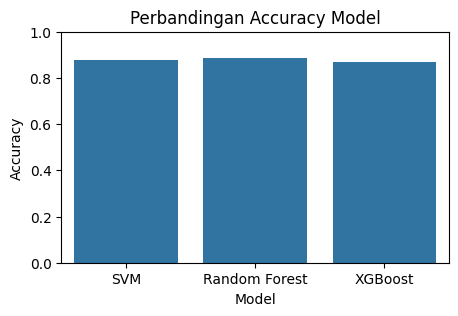

In [44]:
plt.figure(figsize=(5,3))

sns.barplot(
    data=hasil_df,
    x='Model',
    y='Accuracy'
)

plt.title('Perbandingan Accuracy Model')
plt.ylabel('Accuracy')
plt.ylim(0,1)

plt.show()

###**Visualisasi Semua Metrik**

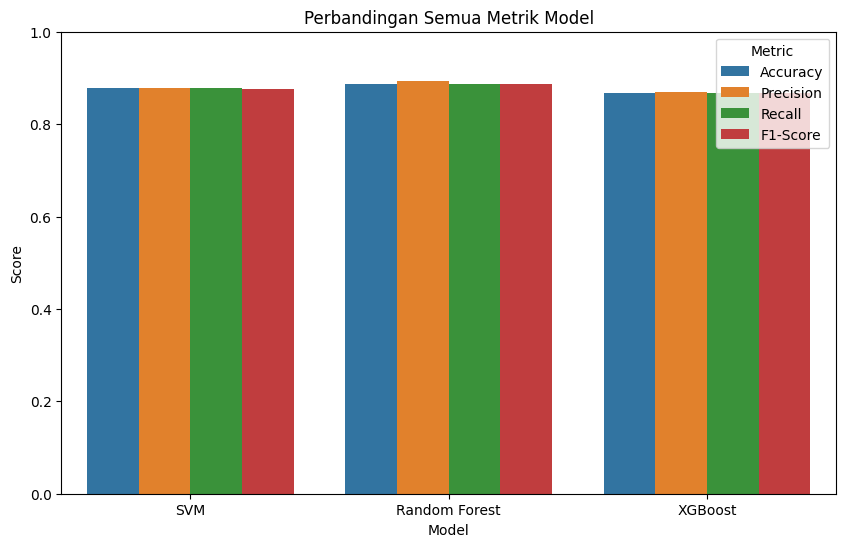

In [45]:
hasil_melt = hasil_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=hasil_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Perbandingan Semua Metrik Model')
plt.ylim(0,1)

plt.show()

###**Model Terbaik**

In [46]:
# Mengambil model dengan accuracy tertinggi
model_terbaik = hasil_df.loc[
    hasil_df['Accuracy'].idxmax()
]

tabel_model_terbaik = pd.DataFrame({
    'Keterangan': [
        'Nama Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],

    'Hasil': [
        model_terbaik['Model'],
        round(model_terbaik['Accuracy'], 4),
        round(model_terbaik['Precision'], 4),
        round(model_terbaik['Recall'], 4),
        round(model_terbaik['F1-Score'], 4)
    ]
})

display(tabel_model_terbaik)

,Keterangan,Hasil
0,Nama Model,Random Forest
1,Accuracy,0.8864
2,Precision,0.8923
3,Recall,0.8864
4,F1-Score,0.8858


### **Feature Importance**

Random Forest

In [47]:
# Mengambil nama fitur
feature_names = X.columns

# Mengambil nilai feature importance
importance_rf = rf_model.feature_importances_


feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_rf
})

# Mengurutkan berdasarkan nilai importance terbesar
feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_rf)

,Feature,Importance
5,blood_pressure,0.172121
6,sleep_quality,0.082040
12,academic_performance,0.072118
14,teacher_student_relationship,0.071157
16,social_support,0.069060
3,depression,0.064353
11,basic_needs,0.056008
4,headache,0.053051
19,bullying,0.051781
15,future_career_concerns,0.047313


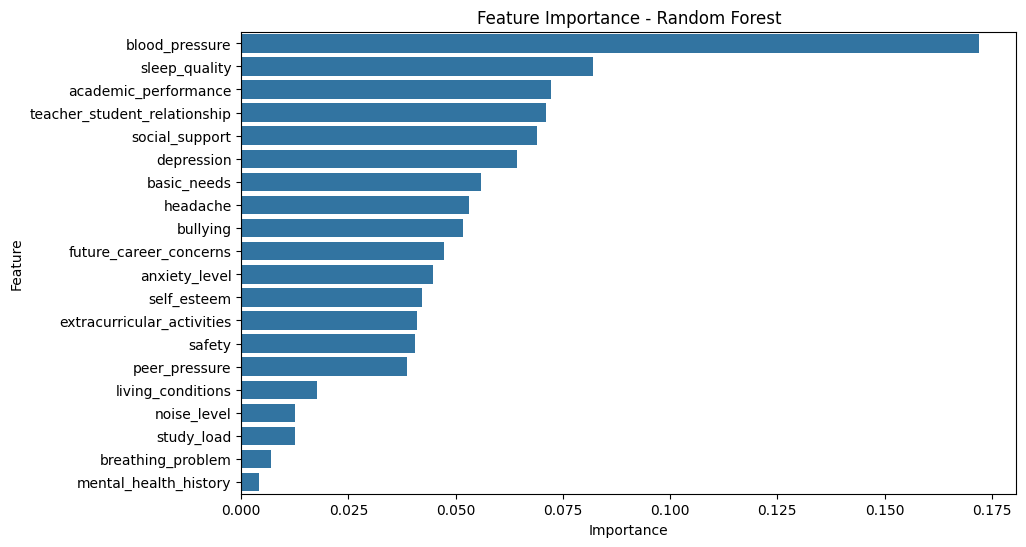

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_rf,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')

plt.show()

XGBoost

In [49]:
# Mengambil nilai feature importance dari XGBoost
importance_xgb = xgb_model.feature_importances_

feature_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_xgb
})

# Mengurutkan berdasarkan nilai importance terbesar
feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_xgb)

,Feature,Importance
5,blood_pressure,0.394267
6,sleep_quality,0.199602
12,academic_performance,0.148503
14,teacher_student_relationship,0.051840
16,social_support,0.040258
11,basic_needs,0.030922
13,study_load,0.018651
15,future_career_concerns,0.014607
18,extracurricular_activities,0.014312
0,anxiety_level,0.012378


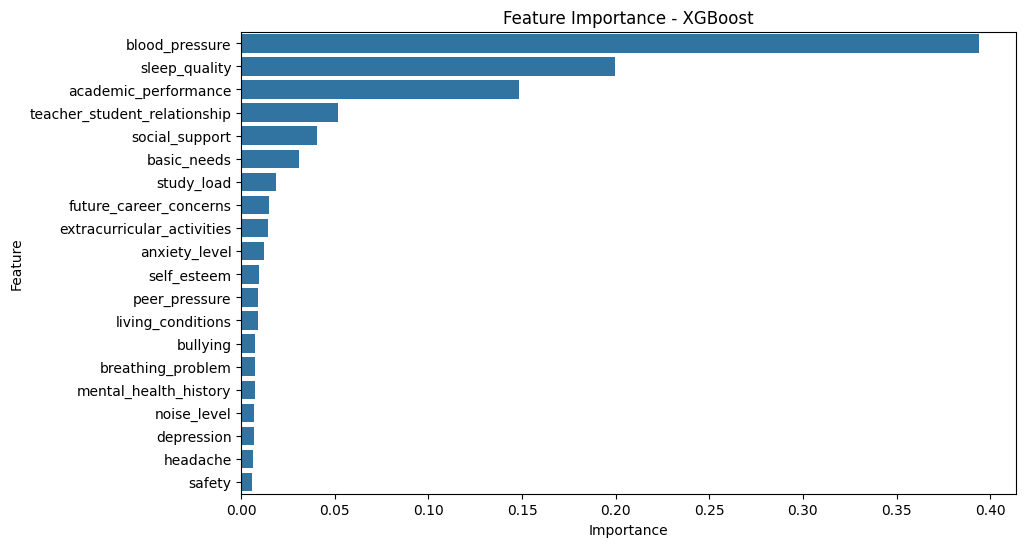

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - XGBoost')

plt.show()

# **CASE 2 - DATA DUMMY**

In [51]:
np.random.seed(42)

In [52]:
df_dummy = df.copy()

###**Membuat Missing Value**

In [53]:
for col in df_dummy.columns[:-1]: # selain target

    df_dummy.loc[
        df_dummy.sample(
            frac=0.05,
            random_state=42
        ).index,
        col
    ] = np.nan

print("JUMLAH MISSING VALUE:")
print(df_dummy.isnull().sum())


JUMLAH MISSING VALUE:
anxiety_level                   55
self_esteem                     55
mental_health_history           55
depression                      55
headache                        55
blood_pressure                  55
sleep_quality                   55
breathing_problem               55
noise_level                     55
living_conditions               55
safety                          55
basic_needs                     55
academic_performance            55
study_load                      55
teacher_student_relationship    55
future_career_concerns          55
social_support                  55
peer_pressure                   55
extracurricular_activities      55
bullying                        55
stress_level                     0
dtype: int64


In [54]:
df_dummy.to_csv(
    'dummy_missing_value_dataset.csv',
    index=False
)

print("Dataset dummy berhasil disimpan")

Dataset dummy berhasil disimpan


### **Visualisasi Missing Value**

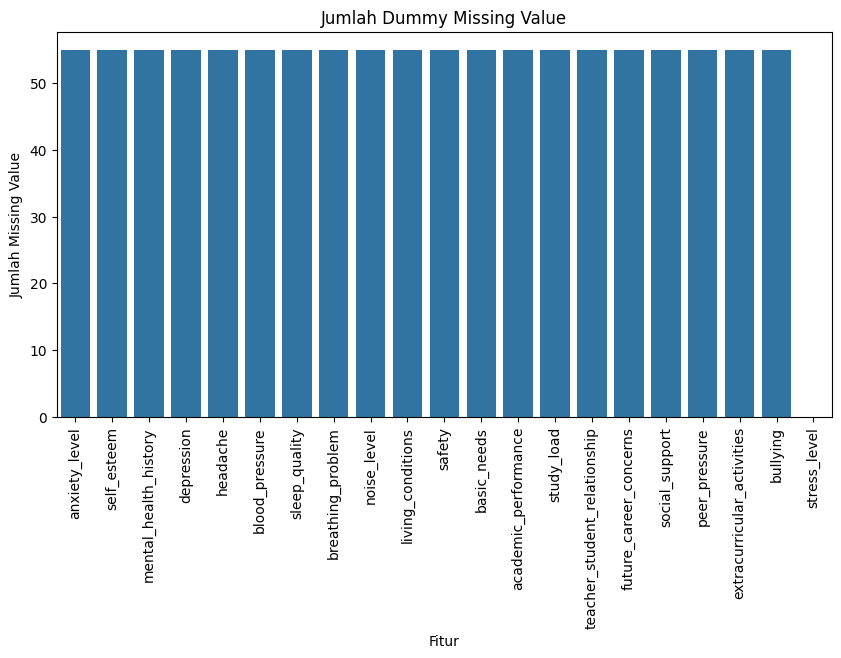

In [55]:
missing_value = df_dummy.isnull().sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_value.index,
    y=missing_value.values
)

plt.title('Jumlah Dummy Missing Value')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Missing Value')

plt.xticks(rotation=90)

plt.show()

### **Imputasi**

In [56]:
# Memisahkan fitur dan target
X_dummy = df_dummy.drop('stress_level', axis=1)
y_dummy = df_dummy['stress_level']

imputer = SimpleImputer(strategy='mean')

X_dummy = imputer.fit_transform(X_dummy)

X_dummy_df = pd.DataFrame(
    X_dummy,
    columns=df_dummy.drop('stress_level', axis=1).columns
)

print("DATA DUMMY SETELAH IMPUTASI")
display(X_dummy_df.head())

DATA DUMMY SETELAH IMPUTASI


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
0,14.0,20.0,0.0,11.0,2.0,1.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,2.0,3.0,3.0,2.0,3.0,3.0,2.0
1,15.0,8.0,1.0,15.0,5.0,3.0,1.0,4.0,3.0,1.0,2.0,2.0,1.0,4.0,1.0,5.0,1.0,4.0,5.0,5.0
2,12.0,18.0,1.0,14.0,2.0,1.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,3.0,2.0,2.0
3,16.0,12.0,1.0,15.0,4.0,3.0,1.0,3.0,4.0,2.0,2.0,2.0,2.0,4.0,1.0,4.0,1.0,4.0,4.0,5.0
4,16.0,28.0,0.0,7.0,2.0,3.0,5.0,1.0,3.0,2.0,4.0,3.0,4.0,3.0,1.0,2.0,1.0,5.0,0.0,5.0


### **Preprocessing Dummy**

Feature Scalling

In [57]:
scaler = StandardScaler()

X_dummy = scaler.fit_transform(X_dummy)

Split Data

In [58]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dummy,
    y_dummy,
    test_size=0.2,
    random_state=42,
    stratify=y_dummy
)

### **Training Ulang Model**

In [59]:
svm_dummy = SVC(
    kernel='rbf',
    random_state=42
)

svm_dummy.fit(X_train_d, y_train_d)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [60]:
rf_dummy = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_dummy.fit(X_train_d, y_train_d)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [61]:
xgb_dummy = XGBClassifier(
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

xgb_dummy.fit(X_train_d, y_train_d)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

### **Prediksi Model**

In [62]:
y_pred_svm_dummy = svm_dummy.predict(X_test_d)
y_pred_rf_dummy = rf_dummy.predict(X_test_d)
y_pred_xgb_dummy = xgb_dummy.predict(X_test_d)

###**Evaluasi Dummy**

In [63]:
def evaluasi_model(nama_model, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(f'{nama_model}')

    print('Accuracy:', round(accuracy, 4))
    print('Precision:', round(precision, 4))
    print('Recall:', round(recall, 4))
    print('F1-Score:', round(f1, 4))

    print()
    print(classification_report(y_test, y_pred))

    return accuracy

In [64]:
svm_dummy_acc = evaluasi_model(
    'SVM',
    y_test_d,
    y_pred_svm_dummy
)

SVM
Accuracy: 0.8682
Precision: 0.8718
Recall: 0.8682
F1-Score: 0.869

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        74
           1       0.93      0.86      0.89        72
           2       0.89      0.86      0.88        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [65]:
rf_dummy_acc = evaluasi_model(
    'Random Forest',
    y_test_d,
    y_pred_rf_dummy
)

Random Forest
Accuracy: 0.8545
Precision: 0.8567
Recall: 0.8545
F1-Score: 0.855

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        74
           1       0.91      0.85      0.88        72
           2       0.85      0.86      0.86        74

    accuracy                           0.85       220
   macro avg       0.86      0.85      0.86       220
weighted avg       0.86      0.85      0.86       220



In [66]:
xgb_dummy_acc = evaluasi_model(
    'XGBoost',
    y_test_d,
    y_pred_xgb_dummy
)

XGBoost
Accuracy: 0.85
Precision: 0.8499
Recall: 0.85
F1-Score: 0.8499

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        74
           1       0.85      0.86      0.86        72
           2       0.86      0.86      0.86        74

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220



### **Hasil Evaluasi Model Dummy**

In [67]:
hasil_dummy_df = pd.DataFrame({

    'Model': [
        'SVM',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [

        accuracy_score(
            y_test_d,
            y_pred_svm_dummy
        ),

        accuracy_score(
            y_test_d,
            y_pred_rf_dummy
        ),

        accuracy_score(
            y_test_d,
            y_pred_xgb_dummy
        )
    ],

    'Precision': [

        precision_score(
            y_test_d,
            y_pred_svm_dummy,
            average='weighted'
        ),

        precision_score(
            y_test_d,
            y_pred_rf_dummy,
            average='weighted'
        ),

        precision_score(
            y_test_d,
            y_pred_xgb_dummy,
            average='weighted'
        )
    ],

    'Recall': [

        recall_score(
            y_test_d,
            y_pred_svm_dummy,
            average='weighted'
        ),

        recall_score(
            y_test_d,
            y_pred_rf_dummy,
            average='weighted'
        ),

        recall_score(
            y_test_d,
            y_pred_xgb_dummy,
            average='weighted'
        )
    ],

    'F1-Score': [

        f1_score(
            y_test_d,
            y_pred_svm_dummy,
            average='weighted'
        ),

        f1_score(
            y_test_d,
            y_pred_rf_dummy,
            average='weighted'
        ),

        f1_score(
            y_test_d,
            y_pred_xgb_dummy,
            average='weighted'
        )
    ]
})

display(hasil_dummy_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.868182,0.871761,0.868182,0.868961
1,Random Forest,0.854545,0.856673,0.854545,0.855031
2,XGBoost,0.850000,0.849938,0.850000,0.849943


### **Confusion Matrix**

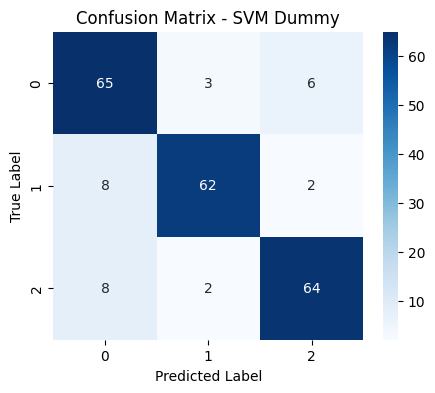

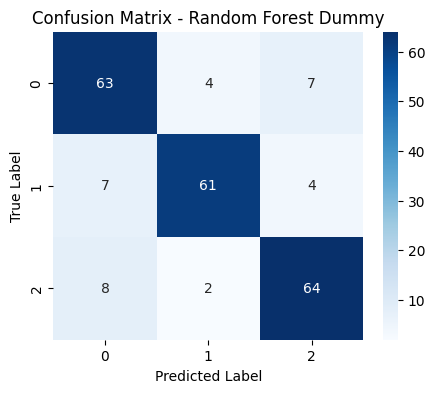

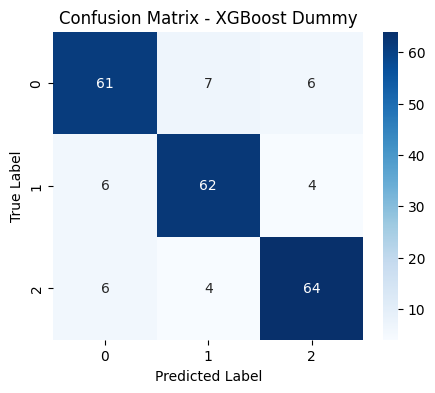

In [68]:
model_dummy = {
    'SVM Dummy': y_pred_svm_dummy,
    'Random Forest Dummy': y_pred_rf_dummy,
    'XGBoost Dummy': y_pred_xgb_dummy
}

for nama_model, y_pred in model_dummy.items():

    cm = confusion_matrix(y_test_d, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {nama_model}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.show()

###**Model Terbaik**

In [69]:
# Mengambil model dengan accuracy tertinggi
model_terbaik_dummy = hasil_dummy_df.loc[
    hasil_dummy_df['Accuracy'].idxmax()
]

tabel_model_dummy = pd.DataFrame({
    'Keterangan': [
        'Nama Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],

    'Hasil': [
        model_terbaik_dummy['Model'],
        round(model_terbaik_dummy['Accuracy'], 4),
        round(model_terbaik_dummy['Precision'], 4),
        round(model_terbaik_dummy['Recall'], 4),
        round(model_terbaik_dummy['F1-Score'], 4)
    ]
})

display(tabel_model_dummy)

,Keterangan,Hasil
0,Nama Model,SVM
1,Accuracy,0.8682
2,Precision,0.8718
3,Recall,0.8682
4,F1-Score,0.869


# **HASIL AKHIR**

Tabel Perbandingan Data Asli & Dummy

In [70]:
# Mengambil accuracy dari data asli
svm_acc = hasil_df.loc[0, 'Accuracy']
rf_acc = hasil_df.loc[1, 'Accuracy']
xgb_acc = hasil_df.loc[2, 'Accuracy']

# Membuat tabel perbandingan
comparison_dummy = pd.DataFrame({

    'Model': [
        'SVM',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy Data Asli': [
        svm_acc,
        rf_acc,
        xgb_acc
    ],

    'Accuracy Data Dummy': [
        svm_dummy_acc,
        rf_dummy_acc,
        xgb_dummy_acc
    ]
})

display(comparison_dummy)

,Model,Accuracy Data Asli,Accuracy Data Dummy
0,SVM,0.8773,0.868182
1,Random Forest,0.8864,0.854545
2,XGBoost,0.8682,0.850000


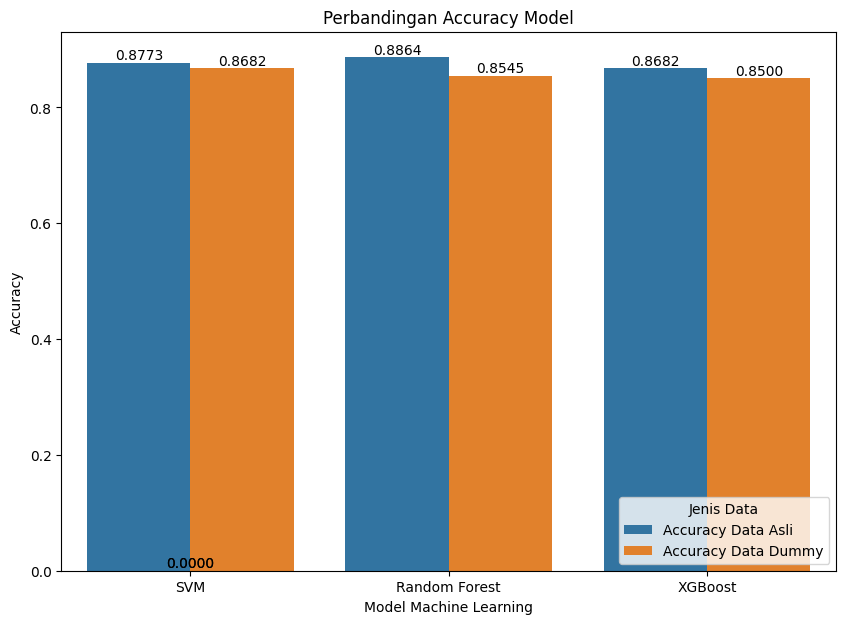

In [71]:
plt.figure(figsize=(10,7))

# Mengubah format data
comparison_melt = comparison_dummy.melt(
    id_vars='Model',
    var_name='Jenis Data',
    value_name='Accuracy'
)

sns.barplot(
    data=comparison_melt,
    x='Model',
    y='Accuracy',
    hue='Jenis Data'
)

plt.title('Perbandingan Accuracy Model')
plt.xlabel('Model Machine Learning')
plt.ylabel('Accuracy')

# Menampilkan nilai accuracy diatas bar
for i in plt.gca().patches:

    plt.gca().annotate(
        f'{i.get_height():.4f}',
        (
            i.get_x() + i.get_width() / 2,
            i.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.show()

In [72]:
perbandingan_lengkap = pd.DataFrame({

    'Model': hasil_df['Model'],

    'Accuracy Asli': hasil_df['Accuracy'],
    'Accuracy Dummy': hasil_dummy_df['Accuracy'],

    'Precision Asli': hasil_df['Precision'],
    'Precision Dummy': hasil_dummy_df['Precision'],

    'Recall Asli': hasil_df['Recall'],
    'Recall Dummy': hasil_dummy_df['Recall'],

    'F1-Score Asli': hasil_df['F1-Score'],
    'F1-Score Dummy': hasil_dummy_df['F1-Score']
})

print("HASIL RINGKASAN DATA ASLI DAN DATA DUMMY")

display(perbandingan_lengkap)

HASIL RINGKASAN DATA ASLI DAN DATA DUMMY


,Model,Accuracy Asli,Accuracy Dummy,Precision Asli,Precision Dummy,Recall Asli,Recall Dummy,F1-Score Asli,F1-Score Dummy
0,SVM,0.8773,0.868182,0.8773,0.871761,0.8773,0.868182,0.8771,0.868961
1,Random Forest,0.8864,0.854545,0.8923,0.856673,0.8864,0.854545,0.8858,0.855031
2,XGBoost,0.8682,0.850000,0.8686,0.849938,0.8682,0.850000,0.8681,0.849943
